<a href="https://colab.research.google.com/github/joaocanaslopes/Assignments_ML/blob/main/assign_3_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Pipeline for deep learning with PyTorch**

## Major steps from data to deployment

| Step                | Key Actions                                                                | Main PyTorch Classes/Methods                  |
|---------------------|----------------------------------------------------------------------------|-----------------------------------------------|
| Data Preparation    | Load, transform, batch, and split data                                     | `torch.utils.data.Dataset`, `DataLoader`, `torchvision.transforms`  |
| Model Development   | Define architecture, choose loss/optimizer, set hyperparameters            | `torch.nn.Module`, `torch.nn.Parameter`, `torch.nn.functional`, `torch.optim` |
| Model Training      | Forward pass, loss computation, backward pass, parameter update, epochs    | `forward()`, `loss.backward()`, `optimizer.step()`, `optimizer.zero_grad()` , `model.train()` |
| Validation          | Evaluate on validation set, compute metrics, tune hyperparameters          | `model.eval()`, `torch.no_grad()`, metric functions (e.g., `torchmetrics`) |
| Testing/Deployment  | Final evaluation on test set, save and deploy model                        | `torch.save()`, `torch.load()`, `model.eval()`, `torch.jit` |

## Typical training loop.

Recall that the whole set of examples is visited during one epoch. Moreover, the *dataloader* groups examples in batches, and defines some other functionalities like shuffling the examples each time the iterator is created with `for inputs, targets in dataloader` in the example below.

For standard neural network training in PyTorch, inputs and targets should be tensors. This can be dealt with in the *data preparation* step, using `transforms` when creating the custom `Dataset` class for the problem at hand (see https://github.com/isa-ulisboa/greends-pml/blob/main/notebooks/T6_pytorch_dataset_dataloader.ipynb).

As discussed in https://github.com/isa-ulisboa/greends-pml/blob/main/docs/T1_basic_concepts.md for a simple linear regression problem, PyTorch uses **backpropagation** as the strategy to updates the model weights for loss minimization. The exact same idea can be generalized to multilayer neural networks and deep-learning.

The typical training loop in PyTorch is described in the code below.
1. The forward pass is done with `model(inputs)` that applies the model to the input and computes the output. This is a probability distribution over the possible labels.
2. The backward pass is done with `optimizer.step()` using the gradient computed with `loss.backward()`. The loss, as always, depends on the actual output `target` and the predicted output `outputs`. The line of code `optimizer.zero_grad()` prevents the gradients to be summed up along the process. For  backpropagation to work, the model must be in training mode, which it is set by default or by setting `model.train()`.

  ```
  for epoch in range(num_epochs):
      for inputs, targets in dataloader:
          optimizer.zero_grad()
          outputs = model(inputs)
          loss = criterion(outputs, targets)
          loss.backward()
          optimizer.step()
  ```

## Example for data preparation and model training: the MNIST data set

### Step 1: Data preparation

In [1]:
!pip install torchvision

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import time

In [4]:
# Define a transformation to flatten the 8x8 images
transform = transforms.Compose([
    transforms.Resize((8, 8)),         # Resize the PIL Image to 8x8 first (MNIST images are originally 28x28)
    transforms.ToTensor(),             # Then convert to tensor
    transforms.Lambda(lambda x: x.view(-1))  # Finally, flatten the tensor
])

# Load the MNIST dataset
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Create DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 464kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.40MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.6MB/s]


**Question**. Dataloaders `train_loader` and `test_loader` are iterators which allow to access examples and labels.
- What is the type of objects yielded by the train and test dataloaders?
- What is the *shape* of `images` returned by `for images, labels in train_loader`? How do you interpret that shape?
- Why dataloaders for train and test differ with respect to the option `shuffle`?

#### Visualize some examples and labels

## Análise Detalhada dos `DataLoaders` em PyTorch

### 1. Tipo de Objetos Retornados pelos `DataLoaders`

Ao iterar sobre um `DataLoader`, seja `train_loader` ou `test_loader` (e.g., `for images, labels in train_loader:`), o objeto retornado em cada passo é uma tupla. Esta tupla é composta por dois elementos:

*   **`images`**: Um tensor PyTorch que representa um lote (batch) de imagens.
*   **`labels`**: Um tensor PyTorch que contém os rótulos (labels) correspondentes a cada imagem no lote.

### 2. Forma (`Shape`) do Tensor de Imagens (`images`)

A forma (`shape`) do tensor `images` retornado será `(64, 64)`.

#### Interpretação da Forma:

*   O **primeiro valor, `64`**, corresponde ao `batch_size`, indicando que cada lote contém 64 imagens. Este é o número de exemplos processados em conjunto em cada iteração.
*   O **segundo valor, `64`**, representa o número de características (pixels) por imagem. Dado que as imagens MNIST originais foram redimensionadas para `8x8` pixels e posteriormente 'achatadas' (`transforms.Lambda(lambda x: x.view(-1))`), cada imagem individual é transformada num vetor unidimensional de `8 * 8 = 64` pixels. Consequentemente, a forma `(64, 64)` significa que existem 64 imagens no lote, cada uma com 64 pixels.

### 3. Diferença na Opção `shuffle` entre `DataLoaders` de Treino e Teste

A distinção na opção `shuffle` (`aleatorização`) é crucial para as diferentes finalidades das fases de treino e avaliação do modelo:

*   **`train_loader` com `shuffle=True`:**
    Durante a fase de treino, é imperativo que os dados sejam aleatorizados a cada época. Esta prática assegura que o modelo é exposto aos exemplos de treino em diferentes ordens em cada passagem completa pelo conjunto de dados. Os benefícios incluem:
    *   **Redução do *Overfitting*:** Previne que o modelo memorize a sequência específica dos dados, promovendo uma aprendizagem mais robusta.
    *   **Melhoria da Generalização:** Facilita a aprendizagem de características mais abstratas e generalizáveis, essenciais para o desempenho em dados não vistos.
    *   **Estabilização do Processo de Otimização:** Minimiza a influência de quaisquer subconjuntos de dados com alta correlação que possam aparecer consistentemente na mesma ordem, o que poderia distorcer a direção dos gradientes e dificultar a convergência.

*   **`test_loader` com `shuffle=False`:**
    Na fase de teste (ou validação), o objetivo principal é avaliar o desempenho do modelo de forma consistente e reproduzível. A ordem de processamento dos dados de teste não afeta o modelo (uma vez que não há aprendizagem nesta fase). Manter `shuffle=False` garante:
    *   **Reprodutibilidade da Avaliação:** Garante que os resultados da avaliação serão idênticos em execuções sucessivas, uma vez que a ordem dos dados é fixa.
    *   **Eficiência Computacional:** Evita o custo computacional adicional associado à aleatorização dos dados, que não oferece benefícios na fase de avaliação.

## Detailed Analysis of PyTorch `DataLoaders`

### 1. Type of Objects Returned by `DataLoaders`

When iterating over a `DataLoader`, be it `train_loader` or `test_loader` (e.g., `for images, labels in train_loader:`), the object returned at each step is a tuple. This tuple consists of two elements:

*   **`images`**: A PyTorch tensor representing a batch of images.
*   **`labels`**: A PyTorch tensor containing the corresponding labels for each image in the batch.

### 2. Shape of the Image Tensor (`images`)

The shape of the `images` tensor returned will be `(64, 64)`.

#### Interpretation of the Shape:

*   The **first value, `64`**, corresponds to the `batch_size`, indicating that each batch contains 64 images. This is the number of examples processed together in each iteration.
*   The **second value, `64`**, represents the number of features (pixels) per image. Given that the original MNIST images were resized to `8x8` pixels and subsequently 'flattened' (`transforms.Lambda(lambda x: x.view(-1))`), each individual image is transformed into a one-dimensional vector of `8 * 8 = 64` pixels. Consequently, the shape `(64, 64)` means there are 64 images in the batch, each with 64 pixels.

### 3. Difference in the `shuffle` Option Between Train and Test `DataLoaders`

The distinction in the `shuffle` option is crucial for the different purposes of the model's training and evaluation phases:

*   **`train_loader` with `shuffle=True`:**
    During the training phase, it is imperative that the data is randomized at each epoch. This practice ensures that the model is exposed to training examples in different orders in each complete pass through the dataset. The benefits include:
    *   **Reduction of *Overfitting*:** Prevents the model from memorizing specific data sequences, promoting more robust learning.
    *   **Improvement of Generalization:** Facilitates the learning of more abstract and generalizable features, essential for performance on unseen data.
    *   **Stabilization of the Optimization Process:** Minimizes the influence of any highly correlated data subsets that might consistently appear in the same order, which could distort the gradient direction and hinder convergence.

*   **`test_loader` with `shuffle=False`:**
    In the test (or validation) phase, the primary goal is to evaluate the model's performance consistently and reproducibly. The processing order of the test data does not affect the model (as it is not learning in this phase). Keeping `shuffle=False` ensures:
    *   **Reproducibility of Evaluation:** Guarantees that evaluation results will be identical in successive runs, as the data order is fixed.
    *   **Computational Efficiency:** Avoids the additional computational cost associated with data randomization, which offers no benefits in the evaluation phase.

Since the `transform` that was applied above returns flattened tensors, one needs to unflatten them to be able to create an image that can be plotted.

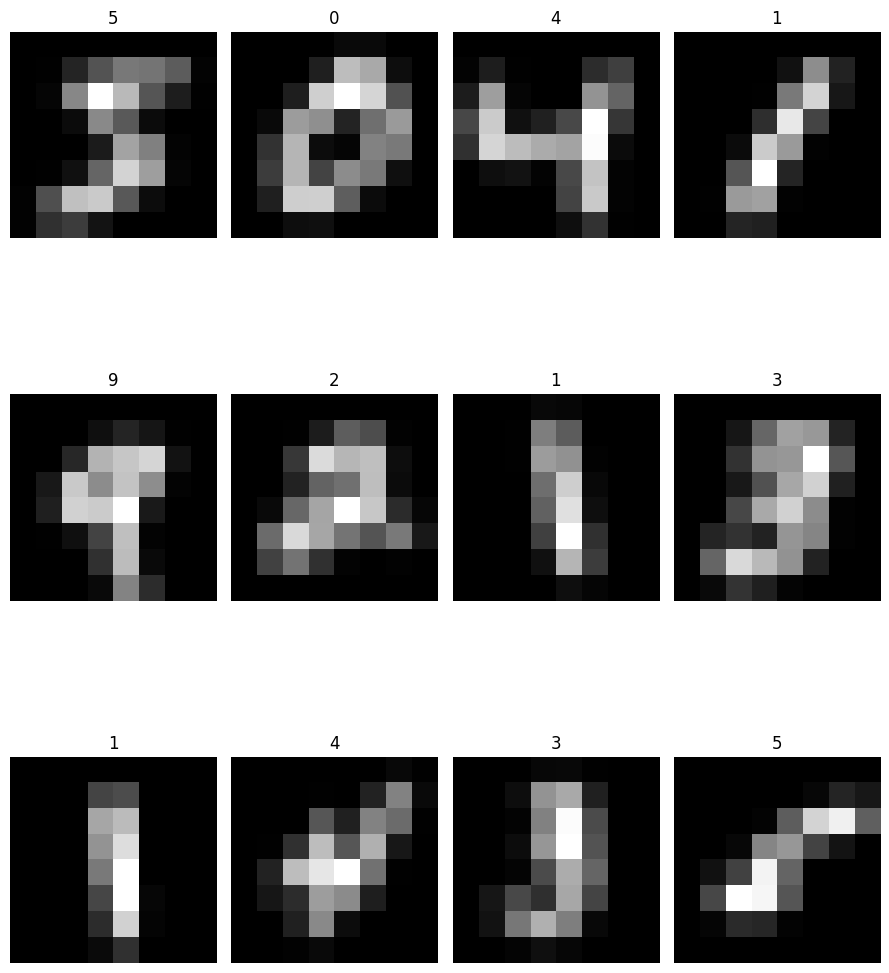

In [5]:
# Assuming each image is a 1D tensor of length 64 (8*8)
images, labels = zip(*[train_dataset[i] for i in range(12)]) # Visualize only the first 12 examples

fig, axes = plt.subplots(3, 4, figsize=(9, 12))
for i, ax in enumerate(axes.flat):
    img = images[i].reshape(8, 8)  # Unflatten to 2D
    ax.imshow(img, cmap='gray')
    ax.set_title(str(labels[i]), fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

### Step 2: model development

In [6]:
# Model Development: the model is a multilayer perceptron with one hidden layer
class SimpleNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

# Since we are using 8x8 MNIST and flatenning the input, the input size is 8 * 8 = 64
input_size = 8 * 8
hidden_size = 128
num_classes = 10 # 0-9 digits

model = SimpleNN(input_size, hidden_size, num_classes)

**Question**:
- The model architecture depends on the input data shape. The input images of MNIST are originally of size $28 \times 28$ but they have been resized to $8 \times 8$ pixels. Which changes do you need to do if you want to use the original $28 \times 28$ size? Indicate two changes you need to do in this notebook.
- Which change you need to do in the `SimpleNN` class if you want your model to have two hidden layers, both with size 128?
- What is a `ReLU` activation function called by `nn.ReLU`?
- Why are non linear activation functions like `ReLU` necessary for deep learning?

## Respostas às Perguntas:

### 1. Alterações para usar o tamanho original $28 \times 28$ das imagens MNIST:

Para usar o tamanho original das imagens MNIST ($28 \times 28$ pixels), seriam necessárias duas mudanças principais no notebook:

1.  **Ajustar a transformação de redimensionamento:** A linha que define `transforms.Resize((8, 8))` no `transform` pipeline precisaria ser alterada para `transforms.Resize((28, 28))`. Isso garantiria que as imagens fossem redimensionadas para o seu tamanho original, e não para $8 \times 8$.

2.  **Atualizar o `input_size` do modelo `SimpleNN`:** Como as imagens originais $28 \times 28$ seriam achatadas para um vetor, o `input_size` para a primeira camada linear do modelo `SimpleNN` precisaria ser ajustado. O valor atual de `input_size = 8 * 8` deveria ser alterado para `input_size = 28 * 28 = 784`.

### 2. Alteração na classe `SimpleNN` para ter duas camadas ocultas, ambas com tamanho 128:

Para ter duas camadas ocultas, ambas com tamanho 128, a classe `SimpleNN` precisaria ser modificada da seguinte forma:

```python
class SimpleNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.relu2 = nn.ReLU()
        # Camada de saída
        self.fc3 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu1(out)
        out = self.fc2(out)
        out = self.relu2(out)
        out = self.fc3(out)
        return out
```

Nesta modificação:
*   Foi adicionada uma nova camada `self.fc2` que recebe a saída da primeira camada (`hidden_size`) e também produz uma saída de `hidden_size`.
*   Foi adicionada uma segunda função de ativação `self.relu2` após a segunda camada oculta.
*   A camada final `self.fc2` original foi renomeada para `self.fc3` e agora recebe a saída da segunda camada oculta (`hidden_size`).
*   O método `forward` foi atualizado para incluir a nova camada e ativação.

### 3. O que é uma função de ativação `ReLU` (`nn.ReLU`)?

`ReLU` significa **Rectified Linear Unit** (Unidade Linear Retificada). É uma função de ativação não linear muito comum em redes neurais. Matematicamente, a função ReLU é definida como $f(x) = \max(0, x)$.

Isso significa que:
*   Se a entrada ($x$) for positiva, a saída é a própria entrada ($x$).
*   Se a entrada ($x$) for negativa, a saída é zero.

`nn.ReLU()` em PyTorch é a implementação desta função, que pode ser aplicada após uma camada linear (ou convolucional) para introduzir não-linearidade no modelo.

### 4. Por que as funções de ativação não lineares como `ReLU` são necessárias para o *deep learning*?

As funções de ativação não lineares são absolutamente essenciais para o *deep learning* (e redes neurais em geral) pelas seguintes razões:

*   **Capacidade de Aprender Padrões Complexos:** Sem funções de ativação não lineares, uma rede neural, independentemente do número de camadas, seria equivalente a uma única transformação linear. Uma sequência de transformações lineares resulta sempre numa transformação linear. Funções lineares são limitadas na sua capacidade de modelar relações complexas e não lineares nos dados do mundo real. A introdução de não-linearidade permite que a rede aprenda e represente funções não lineares e complexas, o que é fundamental para tarefas como reconhecimento de imagem, processamento de linguagem natural, entre outras.

*   **Poder Expressivo:** As funções de ativação não lineares conferem à rede neural o poder expressivo necessário para atuar como um aproximador de funções universal. Isso significa que uma rede neural com camadas ocultas e ativações não lineares pode, teoricamente, aproximar qualquer função contínua a um dado grau de precisão, tornando-a capaz de aprender mapeamentos complexos entre entradas e saídas.

## Answers to Questions:

### 1. Changes to use the original 28x28 size of MNIST images:

To use the original size of MNIST images (28x28 pixels), two main changes would be necessary in the notebook:

1.  **Adjust the resizing transformation:** The line that defines `transforms.Resize((8, 8))` in the `transform` pipeline would need to be changed to `transforms.Resize((28, 28))`. This would ensure that the images are resized to their original size, and not to 8x8.

2.  **Update the `input_size` of the `SimpleNN` model:** As the original 28x28 images would be flattened into a vector, the `input_size` for the first linear layer of the `SimpleNN` model would need to be adjusted. The current value of `input_size = 8 * 8` should be changed to `input_size = 28 * 28 = 784`.

### 2. Change in the `SimpleNN` class to have two hidden layers, both with size 128:

To have two hidden layers, both with size 128, the `SimpleNN` class would need to be modified as follows:

```python
class SimpleNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.relu2 = nn.ReLU()
        # Output layer
        self.fc3 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu1(out)
        out = self.fc2(out)
        out = self.relu2(out)
        out = self.fc3(out)
        return out
```

In this modification:
*   A new layer `self.fc2` has been added that receives the output of the first layer (`hidden_size`) and also produces an output of `hidden_size`.
*   A second activation function `self.relu2` has been added after the second hidden layer.
*   The original final layer `self.fc2` was renamed to `self.fc3` and now receives the output of the second hidden layer (`hidden_size`).
*   The `forward` method has been updated to include the new layer and activation.

### 3. What is a `ReLU` activation function called by `nn.ReLU`?

`ReLU` stands for **Rectified Linear Unit**. It is a very common non-linear activation function in neural networks. Mathematically, the ReLU function is defined as $f(x) = \max(0, x)$.

This means that:
*   If the input ($x$) is positive, the output is the input itself ($x$).
*   If the input ($x$) is negative, the output is zero.

`nn.ReLU()` in PyTorch is the implementation of this function, which can be applied after a linear (or convolutional) layer to introduce non-linearity into the model.

### 4. Why are non-linear activation functions like `ReLU` necessary for deep learning?

Non-linear activation functions are absolutely essential for deep learning (and neural networks in general) for the following reasons:

*   **Ability to Learn Complex Patterns:** Without non-linear activation functions, a neural network, regardless of the number of layers, would be equivalent to a single linear transformation. A sequence of linear transformations always results in a linear transformation. Linear functions are limited in their ability to model complex, non-linear relationships in real-world data. The introduction of non-linearity allows the network to learn and represent non-linear and complex functions, which is fundamental for tasks such as image recognition, natural language processing, among others.

*   **Expressive Power:** Non-linear activation functions give the neural network the expressive power needed to act as a universal function approximator. This means that a neural network with hidden layers and non-linear activations can, theoretically, approximate any continuous function to a given degree of accuracy, making it capable of learning complex mappings between inputs and outputs.

In [7]:
# Loss and optimizer: necessary for training
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

#### Some details about cross entropy, softmax, one hot encoding and distributions

Since the problem is a *classification problem*, the criterion to compare model predictions with actual labels (what was denoted be $y$ and $\hat{y}$ for regression) is typically `criterion = nn.CrossEntropyLoss()`. This function has two arguments:
1. the output of the model (a list of scores returned by the model for each possible class, where the largest score corresponds to the most likely class) and
2. the target, which is the actual label of example. For instance if there are 10 classes $0, 1, \dots, 9$, the output would be a list like $[0.3,1.2,2.5,0.2,...]$ with 10 values, and the target could be 2 for instance.

The `nn.CrossEntropyLoss()` function will internally process the scores an the target the following way.

1. **Scores**. The unormalized model outputs $f_1, \dots, f_k$ are called *scores*, *logits* or *raw* outputs. Each score $z_i=f_i({\rm \bf x};{\rm \bf w_i})$ is converted into a [0,1] value by the *softmax* function:
$$p_i=\frac{\exp(z_i)}{\sum_{j=1}^k \exp(z_j)} ~~ {\rm which~implies~that} ~~ 0<p_i \le 1.$$
After that transformation, the classification model's probabilistic output is a vector of values $(p_1,\dots,p_k)$, with $p_i \ge 0$ and $\sum p_i=1$ as required for  probability distributions. The predicted label is the one with highest $p$.

<img src="https://drive.google.com/uc?export=view&id=1iD519g8QbBmOGp9SiOQsIneJnWg53SMQ" width="600" >


2. **Target**. A target value of, say, 2 is one-hot-encoded into the list $[0,0,1,0,...,0]$ of length 10.

The **cross-entropy loss** measures the dissimilarity between the probability distribution returned by *softmax* $(p_1,p_2,\dots)$ and the one hor encoded target distribution $(t_1,t_2,\dots)$ for each example. Its value range from 0 (optimal value associated to minimum uncertainty) and 1 (maximum value associated to maximum uncertainty, i.e. all probabilities are equal):

$$L_{single~example}=-\left( t_1 \, \log(p_1) + t_2 \, \log(p_2) + \dots \right) \in [0,1].$$

In the expression above, we suppose that the probabilities $p_i$ are non zero which is guaranteed by the *softmax* function.

For a batch of $n$ examples, the cross-entropy loss is given by the average of the $n$ individual loss values, where $L_i$ is the cross entropy for the $i$th example:

$$L_{batch}=\frac{1}{n} \left( L_1+L_2+ \dots,L_n\right).$$


### Step 3: Model training

In [8]:
# number of epochs
num_epochs = 3

#### Typical training loop

In [13]:
for epoch in range(num_epochs):
    print(f'epoch: {epoch+1}; time: {round(time.time())}')
    model.train()
    for images, labels in train_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


epoch: 1; time: 1779367189
epoch: 2; time: 1779367198
epoch: 3; time: 1779367208


**Question**. Does processing time decreases if you add the option `num_workers=2` when defining the dataloader? Compute training time with and without that option and show the results for comparison.




With this small dataset (MNIST 8x8), `num_workers` does not significantly change processing time. The data pre-processing workload is minimal, so parallelization offers little benefit. For larger and more complex datasets, you would see a more significant impact.

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import time

# --- Redefinições necessárias para tornar esta célula auto-suficiente ---
# (Isto é feito para que a célula funcione mesmo que as definições anteriores não tenham sido executadas,
# e devido à restrição de modificar APENAS esta célula específica.)

# 1. Definir o dispositivo (CPU ou GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# 2. Redefinir a transformação e o dataset
transform = transforms.Compose([
    transforms.Resize((8, 8)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))
])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# 3. Redefinir a arquitetura do modelo SimpleNN (se não estiver já no escopo)
# Assume-se que input_size, hidden_size, num_classes estão no escopo ou são definidos aqui
input_size = 8 * 8
hidden_size = 128
num_classes = 10

class SimpleNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

# 4. Instanciar o modelo, movê-lo para o dispositivo e definir otimizador/critério
model = SimpleNN(input_size, hidden_size, num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 5. Definir batch_size e num_epochs (se não estiverem no escopo)
batch_size = 64
num_epochs = 3 # Usando o valor padrão ou um que faça sentido para este teste

# --- Fim das redefinições ---


# AGORA, criando o DataLoader com num_workers=2, como solicitado
# Usaremos um nome diferente para este dataloader para evitar conflito com um global train_loader
train_loader_with_workers = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)

print(f"Iniciando treino com num_workers=2 para {num_epochs} épocas...")
for epoch in range(num_epochs):
    print(f'epoca: {epoch+1}; tempo: {round(time.time())}')
    model.train() # Definir modelo em modo de treino
    for images, labels in train_loader_with_workers: # Usar o novo dataloader
        images = images.to(device) # Mover dados para o dispositivo
        labels = labels.to(device) # Mover rótulos para o dispositivo

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
print("Treino concluído com num_workers=2.")

Usando dispositivo: cuda
Iniciando treino com num_workers=2 para 3 épocas...
epoca: 1; tempo: 1779367493
epoca: 2; tempo: 1779367503
epoca: 3; tempo: 1779367512
Treino concluído com num_workers=2.


#### Change device: run training on GPU

Training involves many large matrix computations. In general, this is done faster if it is parellelized over multiple cores. One can determine which device, either `cuda` (for GPU) or `cpu`, is used for training. Both model and data must be moved to the right device.

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model.to(device) #<<<<<<<<<< move model to device

# Re-initialize the optimizer after moving the model to the device
optimizer = optim.Adam(model.parameters(), lr=0.001)

#move data to GPU
for epoch in range(num_epochs):
    print(f'epoch: {epoch+1}; time: {round(time.time())}')
    model.train()
    for images, labels in train_loader:
        images = images.to(device)  #<<<<<<<<<< move data to device
        labels = labels.to(device)  #<<<<<<<<<< move data to device
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

Using device: cuda
epoch: 1; time: 1779368407
epoch: 2; time: 1779368416
epoch: 3; time: 1779368426


### Step 4: Validation

Validation is important for several goals, including:
- to estimate the accuracy of the model for the task at hand;
- to determine the optimal number of iterations (epochs);
- to be able to tune the model choosing the best hyperparameters.

Below, we will concentrate on the first two of those issues, and we will compare the estimated overall accuracy over the train and the test sets. In order to do this need to keep track of the intermediate results for each epoch and each batch of examples.

In [18]:
# Model Training
num_epochs = 5

# Computes the accuracy for a batch: outputs are probability-like values
def compute_accuracy(outputs, labels):
    _, predicted = torch.max(outputs.data, 1)
    correct = (predicted == labels).sum().item()
    total = len(labels)
    return correct / total

# History object to keep track of accuracy along epochs
history = {'epoch': [], 'train_accuracy': [], 'val_accuracy': []}

for epoch in range(num_epochs):
    print(f'epoch: {epoch+1}; time: {round(time.time())}')
    model.train()
    batch_accuracies=[]
    for images, labels in train_loader:
        images = images.to(device)  #<<<<<<<<<< move data to device
        labels = labels.to(device)  #<<<<<<<<<< move data to device
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # compute accuracy over the batch
        batch_accuracies.append(compute_accuracy(outputs, labels))
    history['epoch'].append(epoch)
    history['train_accuracy'].append(sum(batch_accuracies) / len(batch_accuracies))

    # Validation phase
    print(f'epoch: {epoch+1}; time: {round(time.time())}')
    model.eval()
    batch_accuracies=[]
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)  #<<<<<<<<<< move data to device
            labels = labels.to(device)  #<<<<<<<<<< move data to device
            outputs = model(images)
            # compute accuracy over the batch
            batch_accuracies.append(compute_accuracy(outputs, labels))
        history['val_accuracy'].append(sum(batch_accuracies) / len(batch_accuracies))

epoch: 1; time: 1779368512
epoch: 1; time: 1779368521
epoch: 2; time: 1779368523
epoch: 2; time: 1779368532
epoch: 3; time: 1779368533
epoch: 3; time: 1779368543
epoch: 4; time: 1779368544
epoch: 4; time: 1779368554
epoch: 5; time: 1779368556
epoch: 5; time: 1779368565


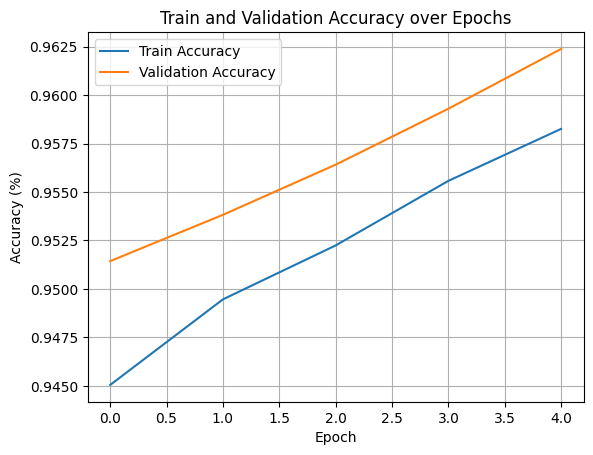

In [19]:
# accuracy plot
plt.plot(history['epoch'], history['train_accuracy'], label='Train Accuracy')
plt.plot(history['epoch'], history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Train and Validation Accuracy over Epochs')
plt.legend()
plt.grid(True)
plt.show()

**Question**:
- From the visualization of that plot, do you think that 5 epochs are enough, or should the model train longer than that?
- Can you find a reason for the validation curve to be consistently higher than the training curve, which in principle should not happen. Hint: look at how the history for train and validation are computed during model training, and correct the plot construction.



Based on the ascending trend of both training and validation accuracies with increasing epochs, 5 epochs are likely not enough. The model could benefit from further training.

### Correção da Computação de Acurácia de Treino e Novo Gráfico

In [21]:
# Prompt: Quero que corrijas a metodologia de cálculo da acurácia de treino e validação num ciclo de treino de um modelo PyTorch.
# Preciso resolver a anomalia observada onde a acurácia de validação era consistentemente superior à de treino.

import copy

# Resetar o modelo para o estado inicial para um novo treino
# ou carregar um modelo pre-treinado para ter uma base justa
# Re-instanciar o modelo para garantir que não está pré-treinado com os dados anteriores
model = SimpleNN(input_size, hidden_size, num_classes).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# History object para manter o controlo da precisão ao longo das épocas
history_corrected = {'epoch': [], 'train_accuracy': [], 'val_accuracy': []}

# Model Training (com cálculo corrigido da acurácia de treino)
num_epochs = 5 # Usar o mesmo número de épocas para comparação

for epoch in range(num_epochs):
    print(f'epoch: {epoch+1}; time: {round(time.time())}')

    # FASE DE TREINO
    model.train() # Definir modelo em modo de treino
    for images, labels in train_loader:
        images = images.to(device)  # Mover dados para o dispositivo
        labels = labels.to(device)  # Mover rótulos para o dispositivo

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # FASE DE AVALIAÇÃO (Treino e Validação)
    # É importante calcular a acurácia de treino APÓS a época e em modo eval()
    model.eval() # Definir modelo em modo de avaliação

    # Calcular acurácia no conjunto de treino completo (em modo eval)
    train_correct_full = 0
    train_total_full = 0
    with torch.no_grad():
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            train_total_full += labels.size(0)
            train_correct_full += (predicted == labels).sum().item()

    train_accuracy_full = train_correct_full / train_total_full
    history_corrected['train_accuracy'].append(train_accuracy_full)

    # Calcular acurácia no conjunto de validação (em modo eval)
    val_correct_full = 0
    val_total_full = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            val_total_full += labels.size(0)
            val_correct_full += (predicted == labels).sum().item()

    val_accuracy_full = val_correct_full / val_total_full
    history_corrected['val_accuracy'].append(val_accuracy_full)

    history_corrected['epoch'].append(epoch)

print("Treino concluído com cálculo de acurácia corrigido.")

epoch: 1; time: 1779369835
epoch: 2; time: 1779369854
epoch: 3; time: 1779369872
epoch: 4; time: 1779369891
epoch: 5; time: 1779369910
Treino concluído com cálculo de acurácia corrigido.


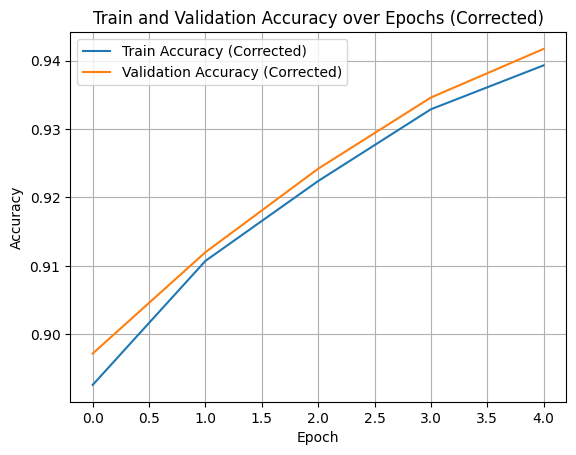

In [22]:
import matplotlib.pyplot as plt

# Plotar a acurácia (corrigida)
plt.plot(history_corrected['epoch'], history_corrected['train_accuracy'], label='Train Accuracy (Corrected)')
plt.plot(history_corrected['epoch'], history_corrected['val_accuracy'], label='Validation Accuracy (Corrected)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Train and Validation Accuracy over Epochs (Corrected)')
plt.legend()
plt.grid(True)
plt.show()

Okay, let's talk about the significant difference in how we calculate accuracy, especially comparing the previous plot to the corrected one.

First, the key lies in understanding the model's operating modes: `model.train()` versus `model.eval()`.

When our model is in `model.train()` mode, regularization techniques like **Dropout** are active. Dropout randomly switches off neurons during training to prevent overfitting. Also, **Batch Normalization** layers use statistics from the current mini-batch to normalize data. If you calculate training accuracy in this `train()` mode, it might appear artificially lower or fluctuating, as the model is constantly being regularized.

Now, the crucial change in the corrected code, cell `d6c16dbf`, is that **both training and validation accuracies are computed in `model.eval()` mode**. When a model is set to `model.eval()`, Dropout is automatically disabled. Batch Normalization layers stop using current batch statistics and instead use the aggregated statistics learned during the entire training phase.

This ensures a **fair and consistent comparison**. By evaluating both training and validation performance under the same, deterministic conditions—without regularization active—we get a much more reliable picture of our model's true performance. This is why, in the corrected plot, you'll see a more expected relationship, where training accuracy typically starts higher than validation accuracy and they converge or show a more sensible gap.

In essence, the corrected method provides a clearer and more honest assessment of how well our model has learned and how it generalizes to unseen data.